# RISNet Exploration Notebook
Aaron Gabrielle Dichoso

In [1]:
import numpy as np
import pandas as pd
import cv2
import os
import PIL.Image as Image
import importlib
import test_utils as utils

In [2]:
include_PVTs = False

## 1. Evaluation of Pre-Trained RISNet

In [3]:
imgs = [utils.get_img_root() + f for f in os.listdir(utils.get_img_root()) if f.endswith('.tif') or f.endswith('.png')]

In [4]:
gts = [utils.get_gt_root() + f for f in os.listdir(utils.get_gt_root()) if f.endswith('.tif') or f.endswith('.png')]

In [5]:
networks = ['C2FNet', 'DaCOD', 'FSPNet', 'HitNet', 'OCENet', 'PFNet', 'PopNet', 'PreyNet', 'RISNet',  'RISNet_ND', 'SINet', 'SINet_V2', 'ZoomNet']
networks_PVTs = ["PreyNet_w_PVT", "SINet_V2_w_PVT"]

if include_PVTs:
    networks = networks + networks_PVTs

In [6]:
pred_roots = ["Results/Default/" + network + "/ACOD-12K/" for network in networks]
preds_networks = [[pred_root + f for f in os.listdir(pred_root) if f.endswith('.tif') or f.endswith('.png')] for pred_root in pred_roots]

In [7]:
plants=["bean", "cucumber", "kiwi", "loquat", "peach", "pepper", "plum", "tomato", "watermelon", "zucchini"]
ACOD_results = {
    plant: [img_dir.split("/")[4] for img_dir in imgs if plant in img_dir]
    for plant in plants
}

In [8]:
img_root_train = "Datasets/ACOD-12K/Train/Imgs/"
img_root = "Datasets/ACOD-12K/Test/Imgs/"

imgs_train = [img_root_train + f for f in os.listdir(img_root_train) if f.endswith('.tif') or f.endswith('.png')]

plants_count = {
    plant: [img_dir.split("/")[4] for img_dir in imgs_train if plant in img_dir]
    for plant in plants
}

In [9]:
train_count = {}
for plant in plants:
    train_count[plant] = len(plants_count[plant])
train_count

{'bean': 39,
 'cucumber': 400,
 'kiwi': 400,
 'loquat': 142,
 'peach': 444,
 'pepper': 760,
 'plum': 212,
 'tomato': 777,
 'watermelon': 549,
 'zucchini': 877}

In [10]:
test_count = {}
for plant in plants:
    test_count[plant] = len(ACOD_results[plant])
list(test_count.values())

[10, 138, 138, 32, 119, 202, 59, 351, 102, 341]

In [11]:
# Add all image files in ACOD_results into one list
ACOD_results_list = [f for plant in ACOD_results for f in ACOD_results[plant]]
ACOD_results_list

['bean_left_00045.png',
 'bean_left_00047.png',
 'bean_left_00048.png',
 'bean_left_00049.png',
 'bean_left_00050.png',
 'bean_left_00051.png',
 'bean_left_00052.png',
 'bean_left_00053.png',
 'bean_left_00054.png',
 'bean_left_00055.png',
 'cucumber_left_00401.png',
 'cucumber_left_00402.png',
 'cucumber_left_00403.png',
 'cucumber_left_00404.png',
 'cucumber_left_00405.png',
 'cucumber_left_00406.png',
 'cucumber_left_00407.png',
 'cucumber_left_00408.png',
 'cucumber_left_00409.png',
 'cucumber_left_00410.png',
 'cucumber_left_00411.png',
 'cucumber_left_00412.png',
 'cucumber_left_00413.png',
 'cucumber_left_00414.png',
 'cucumber_left_00415.png',
 'cucumber_left_00416.png',
 'cucumber_left_00417.png',
 'cucumber_left_00418.png',
 'cucumber_left_00419.png',
 'cucumber_left_00420.png',
 'cucumber_left_00421.png',
 'cucumber_left_00422.png',
 'cucumber_left_00423.png',
 'cucumber_left_00424.png',
 'cucumber_left_00425.png',
 'cucumber_left_00426.png',
 'cucumber_left_00427.png',
 'cu

# Overall Network Performance Test

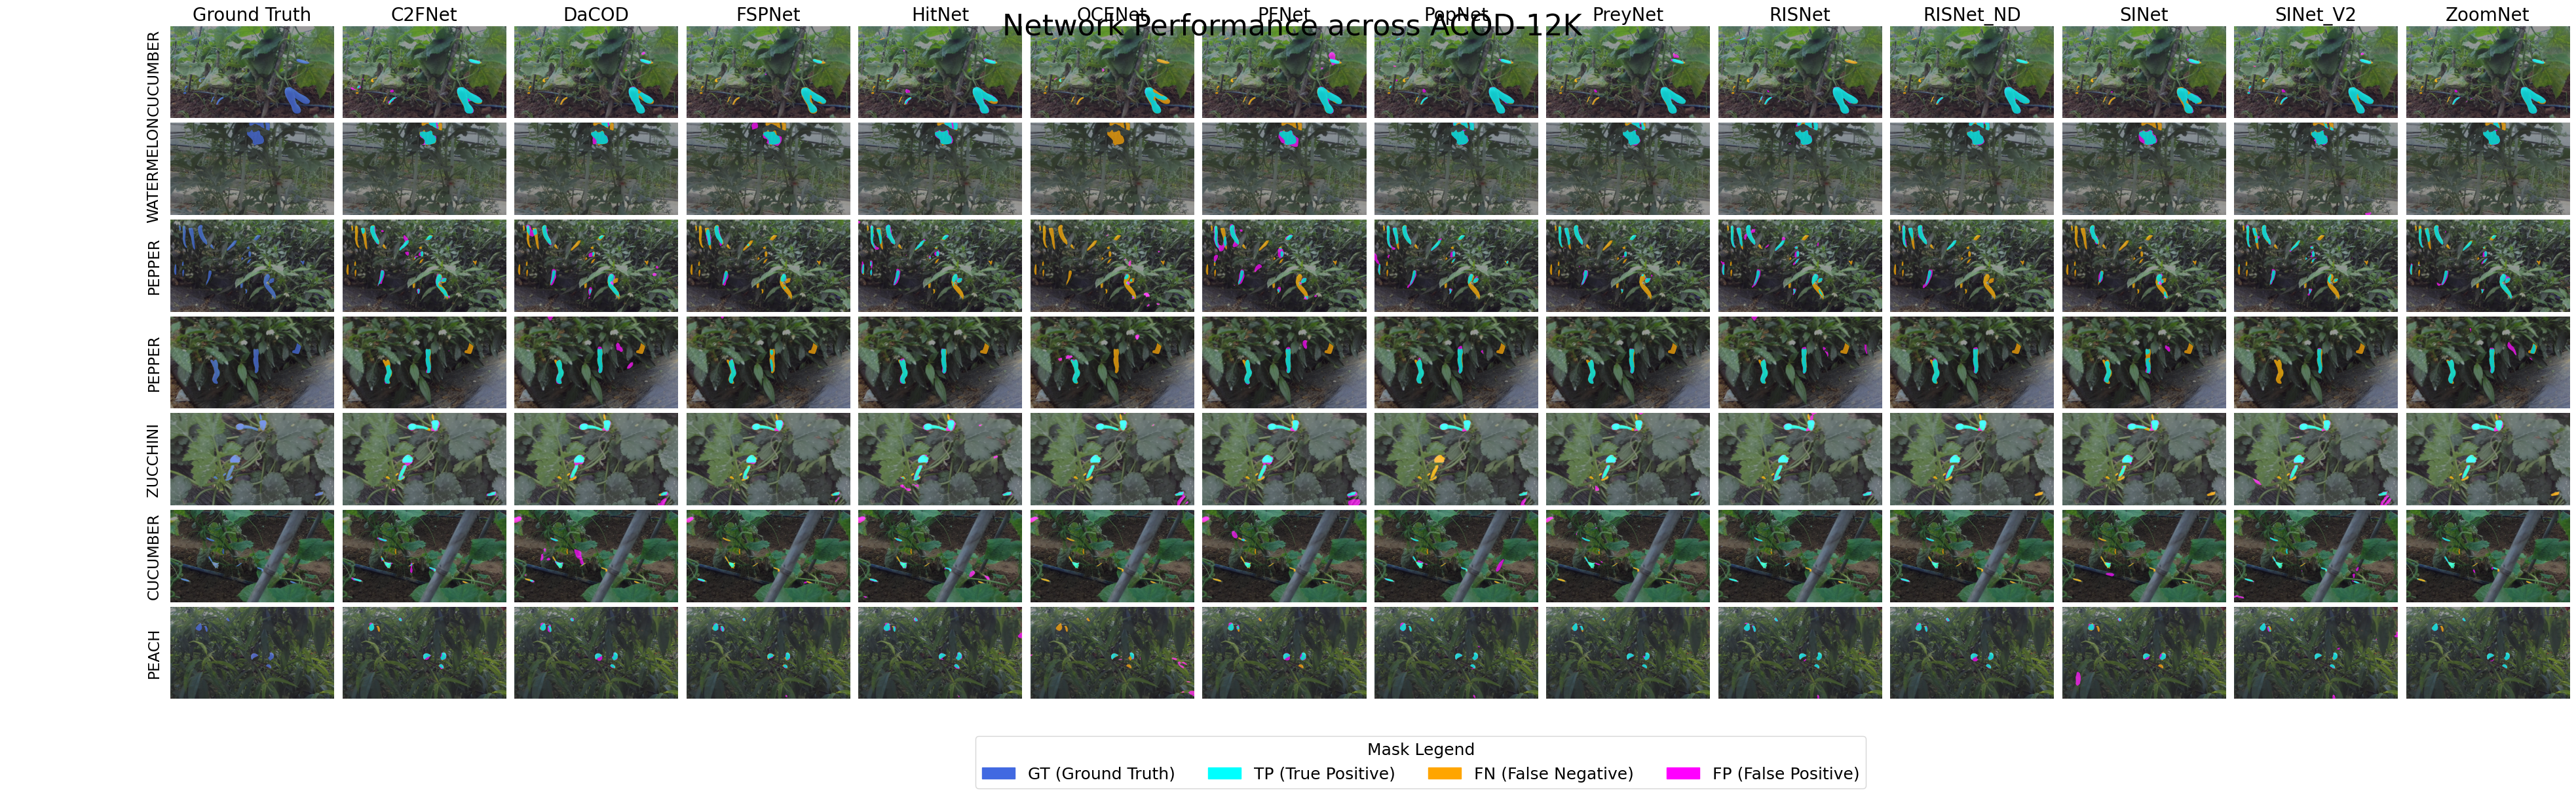

In [12]:
utils.display_images2(images=7, 
                     image_files=ACOD_results_list, 
                     title=f"Network Performance across ACOD-12K", 
                     save_path=f"results-general.png", networks=networks, pred_network_roots=pred_roots)

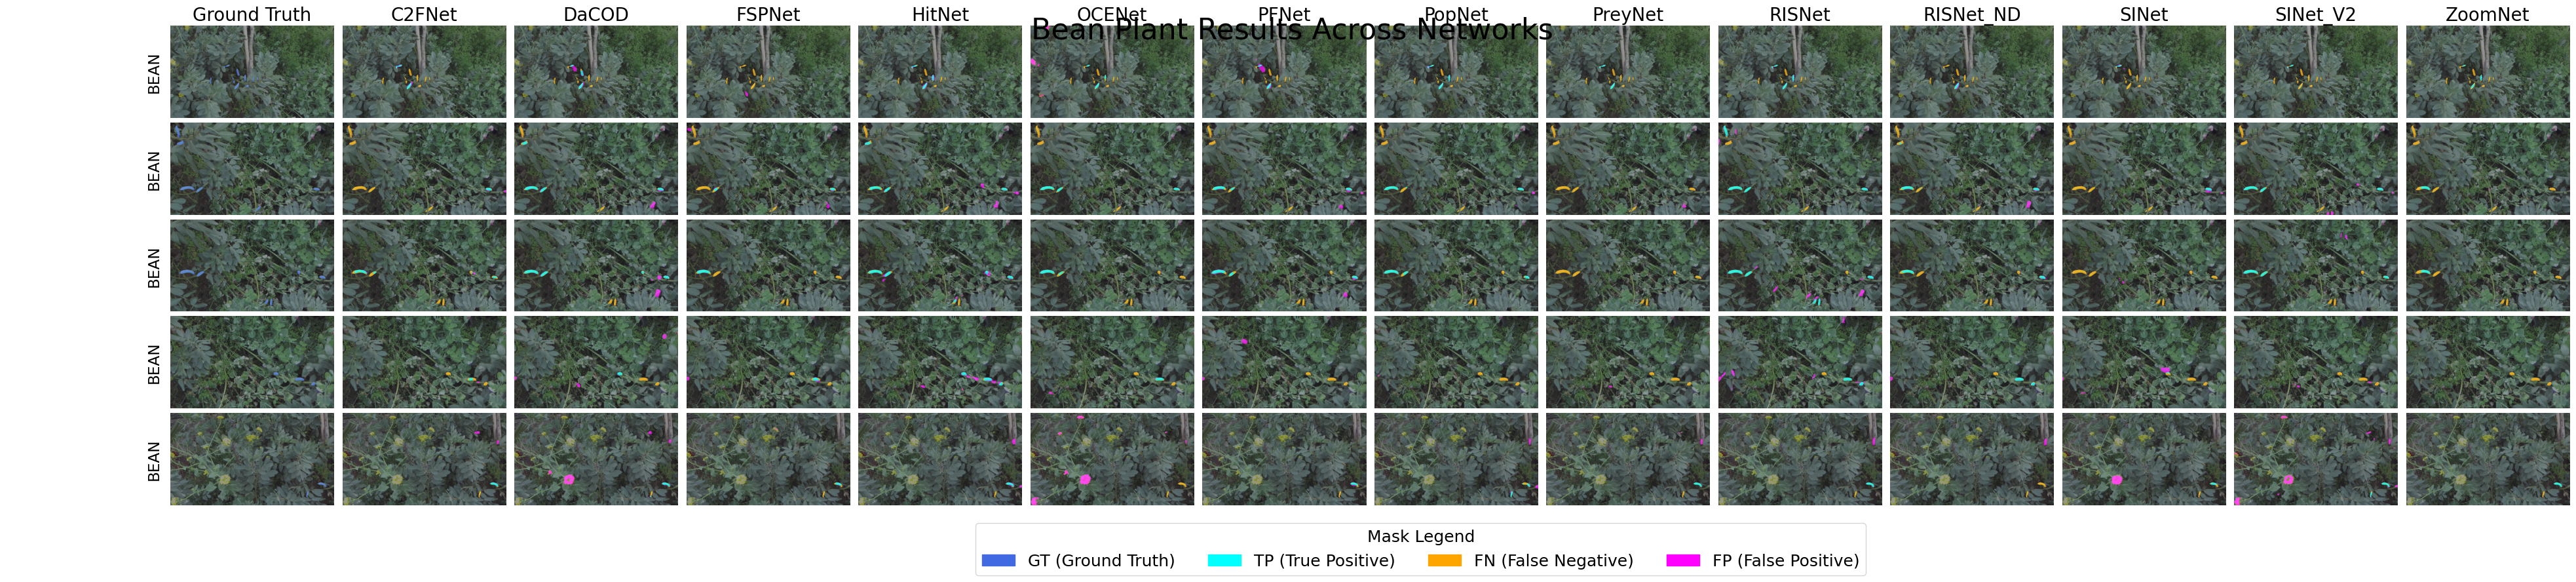

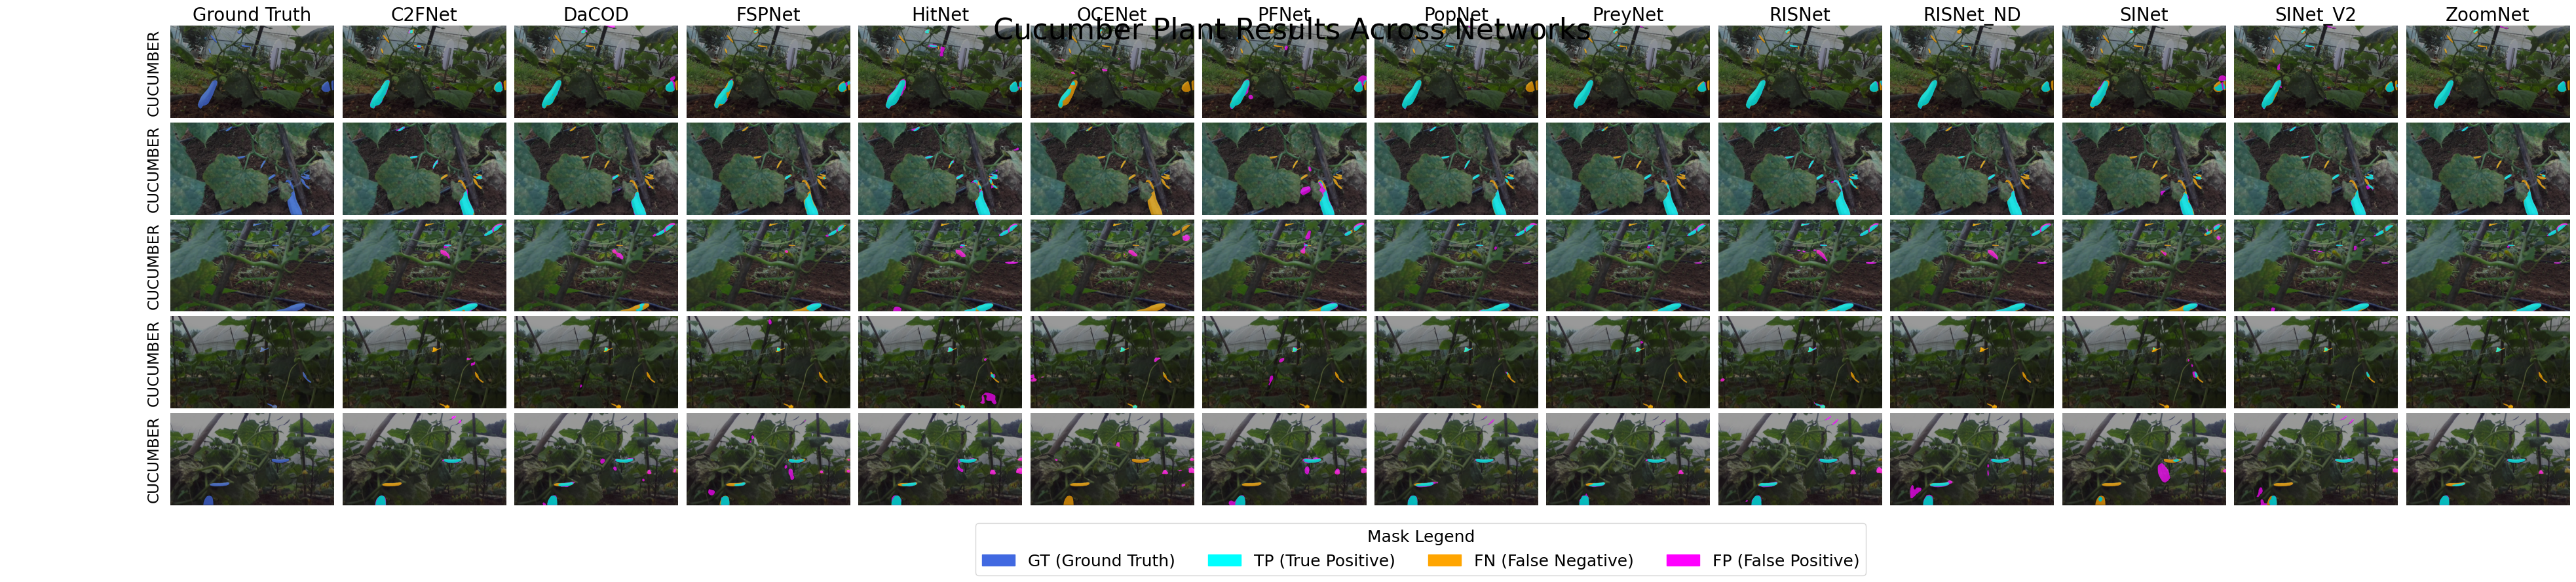

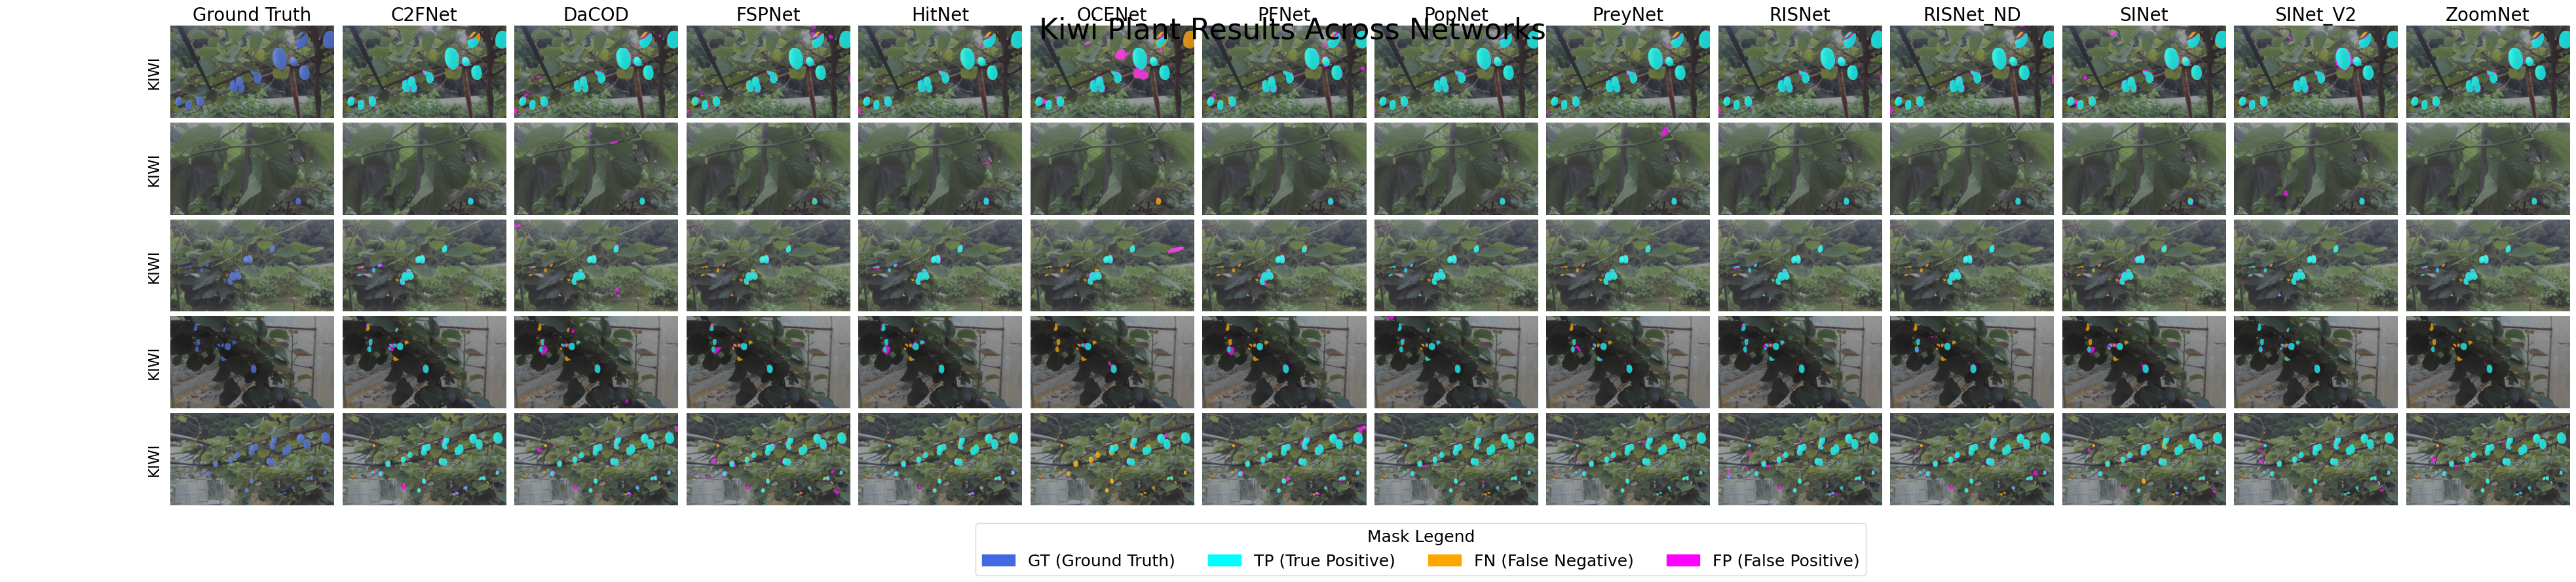

KeyboardInterrupt: 

In [ ]:
for plant in plants:
    utils.display_images2(images=5, image_files=ACOD_results[plant], 
                         title="{} Plant Results Across Networks".format(plant.capitalize()), 
                         save_path="results-{}.png".format(plant), networks=networks, pred_network_roots=pred_roots)

# Performance Comparisons

In [12]:
import pandas as pd

# Read acod_eval_averages.csv
acod_averages_df = pd.read_csv("Data/acod_eval_averages.csv")

# List of networks to exclude
excluded_networks = ["PreyNet_w_PVT", "SINet_V2_w_PVT"]

# Remove them from the DataFrame
acod_averages_df = acod_averages_df[~acod_averages_df["Network"].isin(excluded_networks)]

top_networks = set()
metrics = ['S', 'FWB', 'E']

for metric in metrics:
    top_networks.update(
        acod_averages_df.sort_values(by=[metric], ascending=False)["Network"].head(3).tolist()
    )
print(top_networks)

{'RISNet', 'HitNet', 'PreyNet', 'ZoomNet', 'DaCOD'}


In [13]:
acod_all_df = pd.DataFrame()
for network in networks:
    network_df = pd.read_csv(f"Data/acod_results_{network}.csv")
    acod_all_df = pd.concat([acod_all_df, network_df], ignore_index=True)
    
acod_all_df

,Network,Class,S,FWB,E,MAE,Plant
0,C2FNet,AVERAGE,0.807,0.693,0.954,0.011,NaN
1,C2FNet,NaN,0.593,0.252,0.685,0.006,bean
2,C2FNet,NaN,0.794,0.680,0.951,0.010,cucumber
3,C2FNet,NaN,0.858,0.809,0.978,0.011,kiwi
4,C2FNet,NaN,0.724,0.634,0.981,0.009,loquat
...,...,...,...,...,...,...,...
138,ZoomNet,NaN,0.725,0.513,0.871,0.015,pepper
139,ZoomNet,NaN,0.774,0.616,0.905,0.020,plum
140,ZoomNet,NaN,0.843,0.758,0.954,0.011,tomato
141,ZoomNet,NaN,0.922,0.830,0.964,0.003,watermelon


In [14]:
acod_plant_avgs_df = acod_all_df[~(acod_all_df["Class"]=="AVERAGE")].drop(columns=["Network", "Class", "MAE"]).groupby("Plant").mean().reset_index()
acod_plant_avgs_df.iloc[:, 1:4] *= 100
acod_plant_avgs_df

,Plant,S,FWB,E
0,bean,64.000000,31.515385,75.961538
1,cucumber,77.184615,62.730769,90.884615
2,kiwi,85.369231,79.146154,96.623077
3,loquat,73.838462,60.415385,93.576923
4,peach,76.253846,57.961538,90.084615
5,pepper,67.623077,42.438462,82.853846
6,plum,71.346154,50.646154,85.769231
7,tomato,82.338462,73.015385,94.684615
8,watermelon,86.884615,76.000000,93.015385
9,zucchini,82.961538,73.576923,96.207692


In [15]:
acod_plant_points_df = acod_all_df[(acod_all_df["Plant"].isin(acod_all_df["Plant"].dropna()))].drop(columns=["Class", "MAE"])
acod_plant_points_df.iloc[:, 1:4] *= 100
acod_plant_points_df

,Network,S,FWB,E,Plant
1,C2FNet,59.3,25.2,68.5,bean
2,C2FNet,79.4,68.0,95.1,cucumber
3,C2FNet,85.8,80.9,97.8,kiwi
4,C2FNet,72.4,63.4,98.1,loquat
5,C2FNet,76.9,62.0,95.5,peach
...,...,...,...,...,...
138,ZoomNet,72.5,51.3,87.1,pepper
139,ZoomNet,77.4,61.6,90.5,plum
140,ZoomNet,84.3,75.8,95.4,tomato
141,ZoomNet,92.2,83.0,96.4,watermelon


In [16]:
acod_metric_avg_df = acod_plant_points_df.drop(columns=["Network", "Plant"]).mean()
avg_metrics = dict(set(acod_metric_avg_df.items()))
avg_metrics

{'E': 89.96615384615384, 'S': 76.78000000000002, 'FWB': 60.74461538461538}

C:\Users\Aaron\AppData\Local\Temp\ipykernel_22820\2536623374.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\Aaron\AppData\Local\Temp\ipykernel_22820\2536623374.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\Aaron\AppData\Local\Temp\ipykernel_22820\2536623374.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


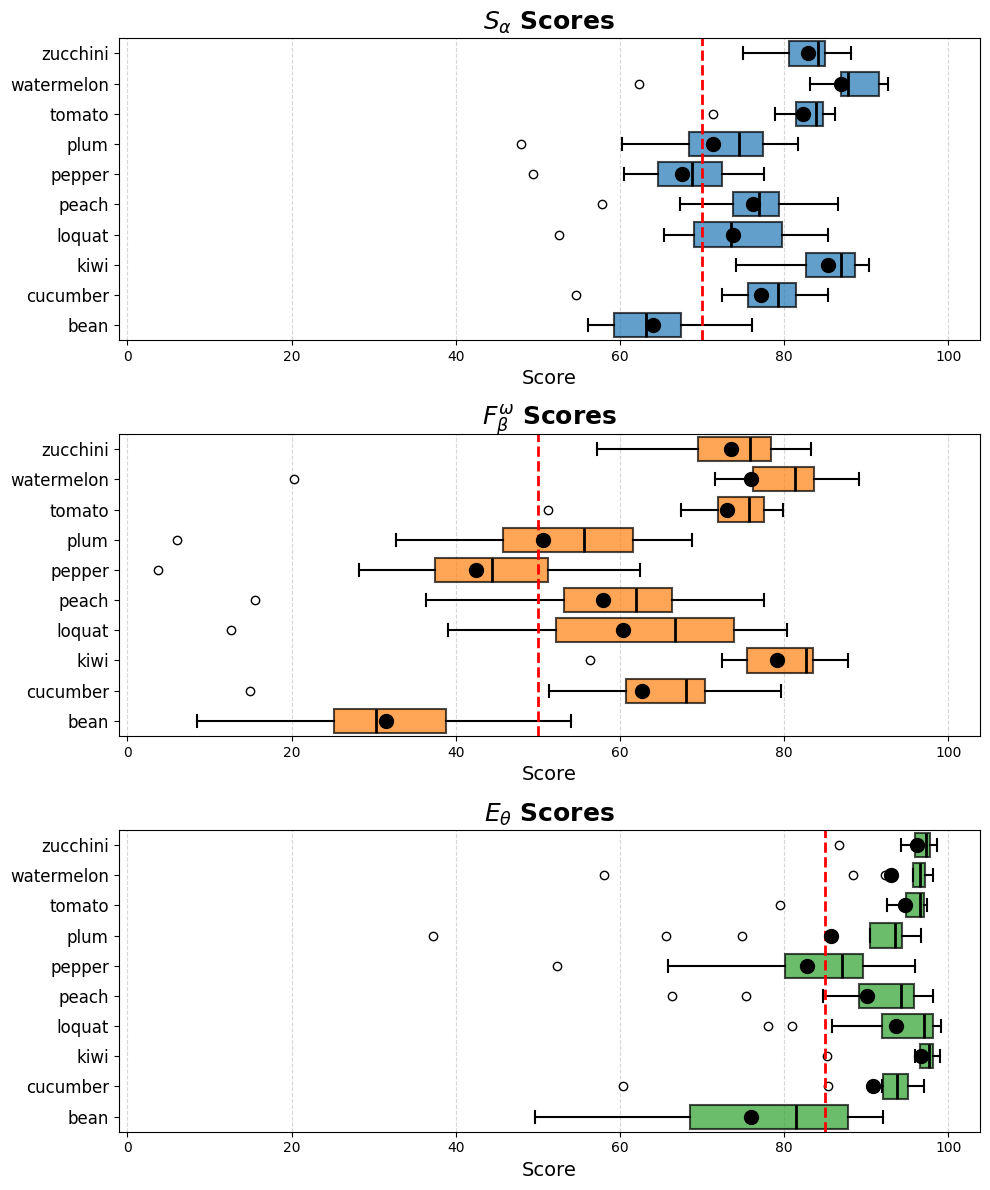

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Configuration
# -----------------------------
MEASURE_COLORS = {
    "S": "#1f77b4",
    "FWB": "#ff7f0e",
    "E": "#2ca02c"
}

MEASURE_GREEK = {
    "S": r"$S_\alpha$",
    "FWB": r"$F^\omega_\beta$",
    "E": r"$E_\theta$"
}

MEASURE_THRESHOLDS = {
    "S": 70,    # Example thresholds, adjust to your values
    "FWB": 50,
    "E": 85
}

AXIS_LABEL_SIZE = 14
TICK_LABEL_SIZE = 12
TITLE_SIZE = 18
NETWORK_FONT_SIZE = 12
FIGSIZE = (10, 12)
BOX_WIDTH = 0.8
MARKER_SIZE = 10

measures = ["S", "FWB", "E"]
plants = sorted(acod_plant_points_df["Plant"].unique())

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(
    nrows=len(measures),
    ncols=1,
    figsize=FIGSIZE,
    sharex=True
)

for ax, measure in zip(axes, measures):

    # Gather all scores for each plant
    data = [acod_plant_points_df.loc[acod_plant_points_df["Plant"] == plant, measure].values for plant in plants]

    bp = ax.boxplot(
        data,
        vert=False,
        patch_artist=True,
        showmeans=True,
        widths=BOX_WIDTH,
        labels=plants
    )

    # Box styling
    for box in bp["boxes"]:
        box.set(facecolor=MEASURE_COLORS[measure], alpha=0.7, linewidth=1.5)

    # Median line
    for median in bp["medians"]:
        median.set(color="black", linewidth=2)

    # Mean markers
    for mean in bp["means"]:
        mean.set(marker="o", markerfacecolor="black", markeredgecolor="black", markersize=MARKER_SIZE)

    # Whiskers and caps
    for whisker in bp["whiskers"]:
        whisker.set(linewidth=1.5)
    for cap in bp["caps"]:
        cap.set(linewidth=1.5)

    # Grid
    ax.grid(axis="x", linestyle="--", alpha=0.5)

    # Threshold line
    ax.axvline(
        x=MEASURE_THRESHOLDS[measure],
        color="red",
        linestyle="--",
        linewidth=2
    )

    # Optional: log scale if needed
    # ax.set_xscale("log")

    # Labels and title
    ax.set_xlabel("Score", fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis="x", labelbottom=True)
    ax.set_title(f"{MEASURE_GREEK[measure]} Scores", fontsize=TITLE_SIZE, fontweight="bold")
    ax.tick_params(axis="y", labelsize=NETWORK_FONT_SIZE)

plt.tight_layout()
plt.show()
fig.savefig("plant_boxplot_by_network.png", dpi=150, bbox_inches="tight")


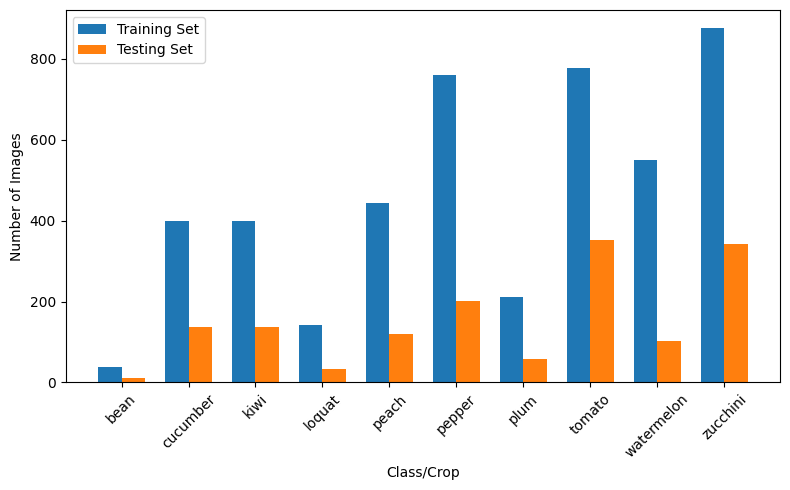

In [18]:
x = np.arange(len(plants))
width = 0.35

fig = plt.figure(figsize=(8, 5))
plt.bar(x - width/2, train_count.values(), width, label="Training Set")
plt.bar(x + width/2, test_count.values(),  width, label="Testing Set")

plt.xticks(x, plants, rotation=45)
plt.ylabel("Number of Images")
plt.xlabel("Class/Crop")
#plt.title("Training vs Testing Image Counts per Plant")
plt.legend()
plt.tight_layout()
plt.show()

fig.savefig("dataset-counts.png", dpi=150, bbox_inches="tight")

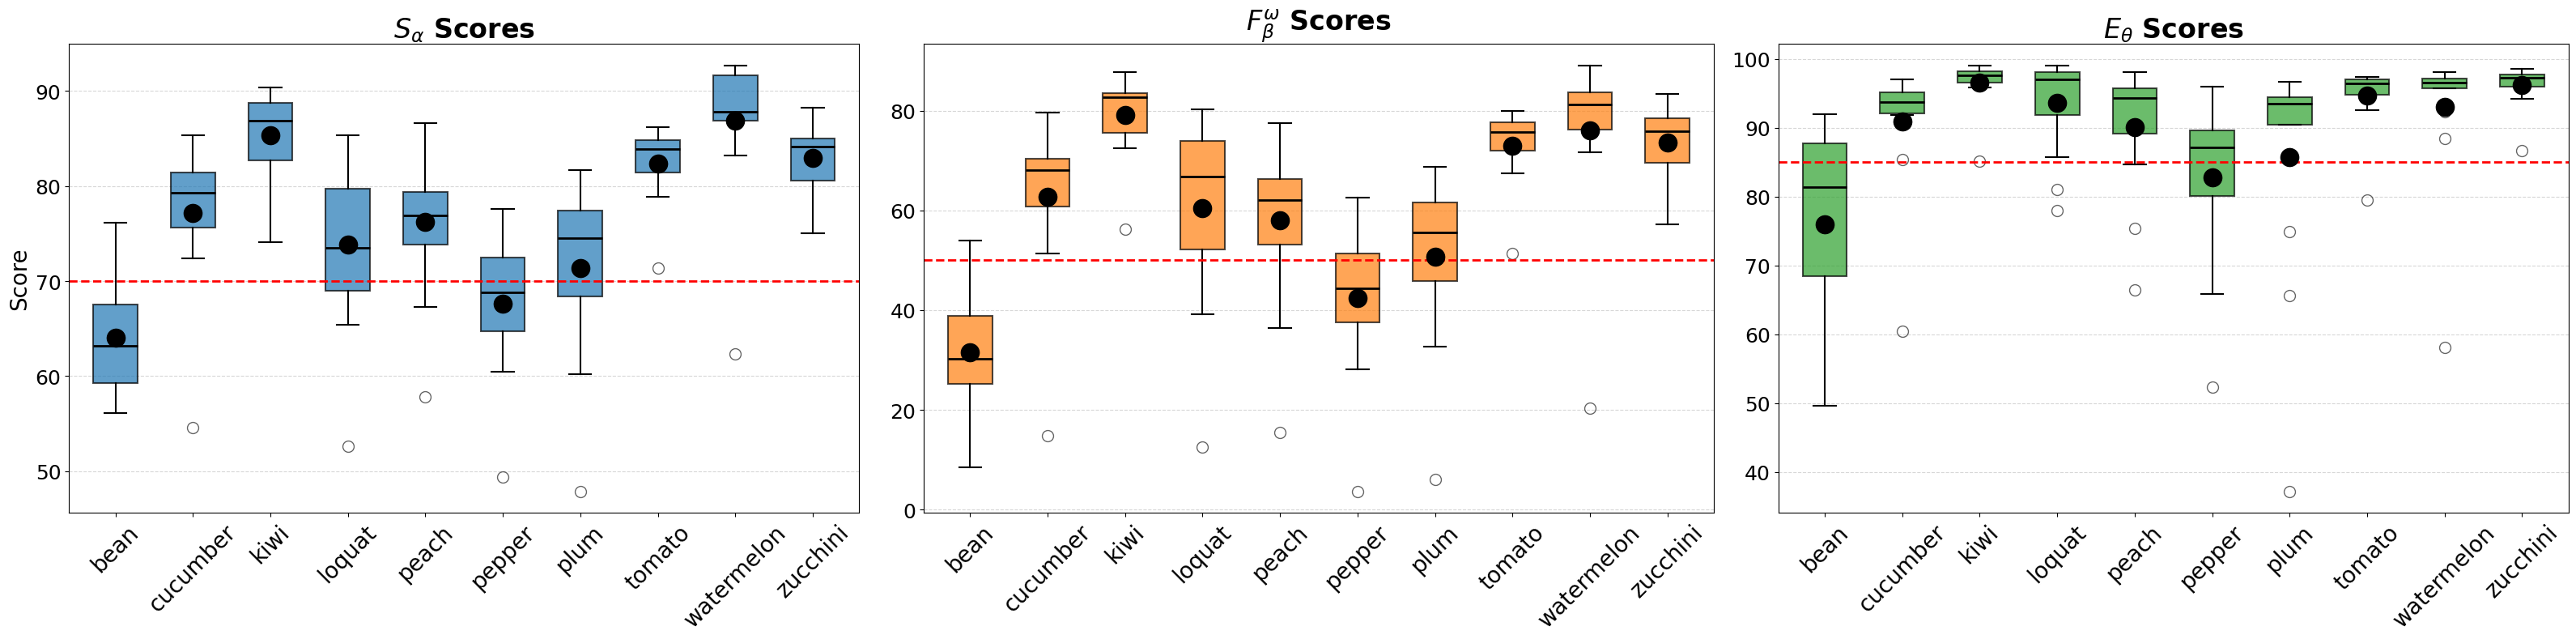

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Configuration
# -----------------------------
MEASURE_COLORS = {
    "S": "#1f77b4",
    "FWB": "#ff7f0e",
    "E": "#2ca02c"
}

MEASURE_GREEK = {
    "S": r"$S_\alpha$",
    "FWB": r"$F^\omega_\beta$",
    "E": r"$E_\theta$"
}

MEASURE_THRESHOLDS = {
    "S": 70,    # Example thresholds, adjust to your values
    "FWB": 50,
    "E": 85
}

AXIS_LABEL_SIZE = 20
TICK_LABEL_SIZE = 18
TITLE_SIZE = 24
NETWORK_FONT_SIZE = 20
FIGSIZE = (32, 8)
BOX_WIDTH = 2.0
MARKER_SIZE = 16
BOX_SPACING = 3.5
EDGE_PADDING = 0.6   

measures = ["S", "FWB", "E"]
plants = sorted(acod_plant_points_df["Plant"].unique())

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(measures),
    figsize=FIGSIZE,
    sharex=True
)

for ax, measure in zip(axes, measures):

    # Gather all scores for each plant
    data = [
        acod_plant_points_df.loc[
            acod_plant_points_df["Plant"] == plant, measure
        ].values
        for plant in plants
    ]

    positions = np.arange(len(plants)) * BOX_SPACING + 1
    bp = ax.boxplot(
        data,
        positions=positions,
        patch_artist=True,
        showmeans=True,
        widths=BOX_WIDTH,
        flierprops=dict(
            marker='o',
            markersize=10,
            alpha=0.6
        )
    )
    
    # Box styling
    for box in bp["boxes"]:
        box.set(facecolor=MEASURE_COLORS[measure], alpha=0.7, linewidth=1.5)

    # Median line
    for median in bp["medians"]:
        median.set(color="black", linewidth=2)

    # Mean markers
    for mean in bp["means"]:
        mean.set(
            marker="o",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=MARKER_SIZE
        )

    # Whiskers and caps
    for whisker in bp["whiskers"]:
        whisker.set(linewidth=1.5)
    for cap in bp["caps"]:
        cap.set(linewidth=1.5)

    # Grid (now on y-axis)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Threshold line (horizontal now)
    ax.axhline(
        y=MEASURE_THRESHOLDS[measure],
        color="red",
        linestyle="--",
        linewidth=2
    )

    # Labels and title
    if measure == "S":
        ax.set_ylabel("Score", fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis="y", labelsize=TICK_LABEL_SIZE)
    ax.set_title(
        f"{MEASURE_GREEK[measure]} Scores",
        fontsize=TITLE_SIZE,
        fontweight="bold"
    )
    ax.tick_params(axis="x", labelsize=NETWORK_FONT_SIZE, labelbottom=True)
    ax.set_xticks(positions)
    ax.set_xticklabels(plants, rotation=45)
    ax.set_xlim(
        positions[0] - EDGE_PADDING * BOX_SPACING,
        positions[-1] + EDGE_PADDING * BOX_SPACING
    )

plt.tight_layout()
plt.show()
fig.savefig("plant_boxplot_by_network.png", dpi=150, bbox_inches="tight")


In [20]:
acod_plant_measures_df = acod_plant_avgs_df.copy()
acod_plant_measures_df.loc[:, "Class"] = "AVERAGE"
difficult_crops = ["bean", "plum", "pepper"]
top_networks_difficult_crops = set()
for plant in plants:
    for metric in metrics:
        #Get best and worst networks for each plant and metric
        plant_metric_df = acod_plant_points_df[
            (acod_all_df["Plant"] == plant)
        ].sort_values(by=[metric], ascending=False)

        # Isolate worst and best and add to acod_plant_measures_df
        best_rows = plant_metric_df.head(3).copy()
        worst_rows = plant_metric_df.tail(3).copy()
        
        best_rows["Class"] = [
            f"{plant.capitalize()}_{metric}_1stB",
            f"{plant.capitalize()}_{metric}_2ndB",
            f"{plant.capitalize()}_{metric}_3rdB",
        ]
        
        worst_rows["Class"] = [
            f"{plant.capitalize()}_{metric}_3rdW",
            f"{plant.capitalize()}_{metric}_2ndW",
            f"{plant.capitalize()}_{metric}_1stW",
        ]
        
        if plant in difficult_crops:
            top_networks_difficult_crops.update(best_rows["Network"].to_list())
        acod_plant_measures_df = pd.concat([acod_plant_measures_df, best_rows, worst_rows], ignore_index=True)


#acod_plant_measures_df.drop(columns=["MAE"], inplace=True)
pd.DataFrame(acod_plant_measures_df).to_csv("Data/acod_plant_measures.csv", index=False)
acod_plant_measures_df

C:\Users\Aaron\AppData\Local\Temp\ipykernel_22820\4079783692.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plant_metric_df = acod_plant_points_df[
C:\Users\Aaron\AppData\Local\Temp\ipykernel_22820\4079783692.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plant_metric_df = acod_plant_points_df[
C:\Users\Aaron\AppData\Local\Temp\ipykernel_22820\4079783692.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plant_metric_df = acod_plant_points_df[
C:\Users\Aaron\AppData\Local\Temp\ipykernel_22820\4079783692.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plant_metric_df = acod_plant_points_df[
C:\Users\Aaron\AppData\Local\Temp\ipykernel_22820\4079783692.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plant_metric_df = acod_plant_points_df[
C:\Users\Aaron\AppData\Local\Temp\ipykernel_22820\4079783692.py:8: UserWarn

,Plant,S,FWB,E,Class,Network
0,bean,64.000000,31.515385,75.961538,AVERAGE,NaN
1,cucumber,77.184615,62.730769,90.884615,AVERAGE,NaN
2,kiwi,85.369231,79.146154,96.623077,AVERAGE,NaN
3,loquat,73.838462,60.415385,93.576923,AVERAGE,NaN
4,peach,76.253846,57.961538,90.084615,AVERAGE,NaN
...,...,...,...,...,...,...
185,zucchini,86.300000,79.900000,98.100000,Zucchini_E_2ndB,OCENet
186,zucchini,85.900000,79.400000,97.900000,Zucchini_E_3rdB,PreyNet
187,zucchini,79.400000,65.600000,95.400000,Zucchini_E_3rdW,SINet
188,zucchini,80.600000,68.200000,94.200000,Zucchini_E_2ndW,FSPNet


In [21]:
top_networks_difficult_crops

{'DaCOD', 'HitNet', 'PFNet', 'PopNet', 'PreyNet', 'RISNet', 'ZoomNet'}

    Network      S    FWB      E    MAE
5     PFNet  0.776  0.636  0.948  0.014
1     DaCOD  0.787  0.660  0.956  0.013
3    HitNet  0.817  0.725  0.963  0.011
6    PopNet  0.820  0.712  0.939  0.010
12  ZoomNet  0.826  0.711  0.936  0.009
7   PreyNet  0.826  0.718  0.941  0.009
8    RISNet  0.859  0.788  0.976  0.008


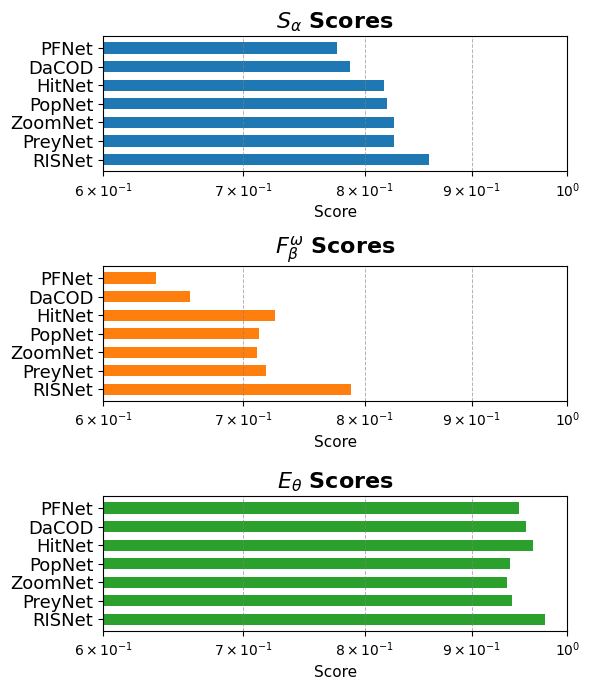

In [22]:
import matplotlib.pyplot as plt

# -----------------------------
# Configuration (paper-ready)
# -----------------------------
MEASURE_COLORS = {
    "S": "#1f77b4",    # blue
    "FWB": "#ff7f0e",  # orange
    "E": "#2ca02c"     # green
}

# Greek symbols for measures (LaTeX-style)
MEASURE_GREEK = {
    "S": r"$S_\alpha$",
    "FWB": r"$F^\omega_\beta$",
    "E": r"$E_\theta$"
}

NETWORK_FONT_SIZE = 13
AXIS_LABEL_SIZE = 11
TICK_LABEL_SIZE = 10
TITLE_SIZE = 16

# -----------------------------
# Data preparation
# -----------------------------
top_df = acod_averages_df[
    acod_averages_df["Network"].isin(top_networks_difficult_crops)
].copy()

top_df.sort_values(by=metrics, ascending=True, inplace=True)

print(top_df)

measures = ["S", "FWB", "E"]

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(
    nrows=len(measures),
    ncols=1,
    figsize=(6, 7),
    sharey=True
)

y = range(len(top_df))

for ax, measure in zip(axes, measures):
    ax.barh(
        y,
        top_df[measure],
        height=0.6,
        color=MEASURE_COLORS[measure]
    )

    ax.set_xscale("log")
    ax.set_xticks([0.6, 0.7, 0.8, 0.9, 1.0])
    ax.set_xlabel("Score", fontsize=AXIS_LABEL_SIZE)

    # Greek symbol title
    ax.set_title(
        f"{MEASURE_GREEK[measure]} Scores",
        fontsize=TITLE_SIZE,
        fontweight="bold"
    )

    # Vertical guidelines
    for xt in ax.get_xticks():
        ax.axvline(
            x=xt,
            color="gray",
            linestyle="--",
            linewidth=0.7,
            alpha=0.6
        )

    # Consistent tick sizes
    ax.tick_params(axis="x", labelsize=TICK_LABEL_SIZE)
    ax.tick_params(axis="y", labelsize=NETWORK_FONT_SIZE)

# Y-axis labels (networks)
axes[0].set_yticks(y)
axes[0].set_yticklabels(
    top_df["Network"],
    fontsize=NETWORK_FONT_SIZE
)
axes[0].invert_yaxis()

plt.tight_layout()
plt.show()

fig.savefig("currentperformance.png", dpi=100, bbox_inches='tight')


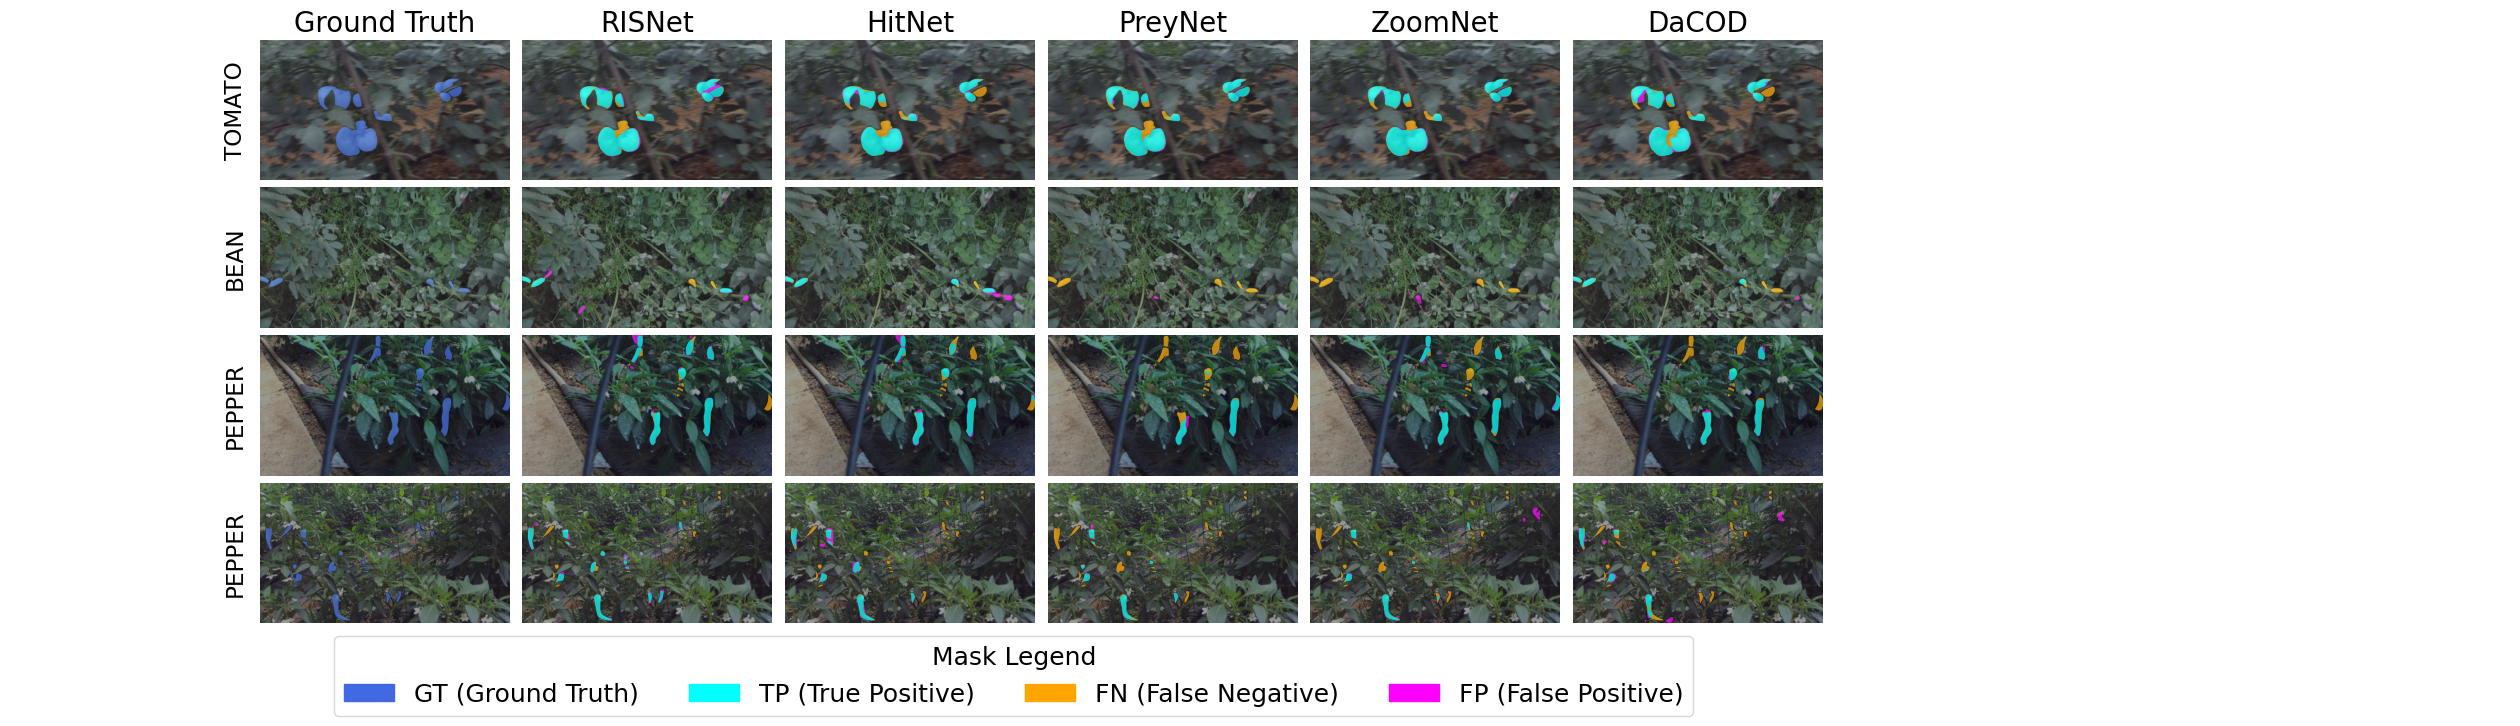

In [23]:
importlib.reload(utils)
top_networks_difficult_crops = list(top_networks_difficult_crops)
top_networks = list(top_networks)
utils.display_images2(images=4, 
                      image_files=ACOD_results_list, 
                      save_path=f"results-top.png", 
                      networks=top_networks, pred_network_roots=["Results/Default/" + network + "/ACOD-12K/" for network in top_networks])

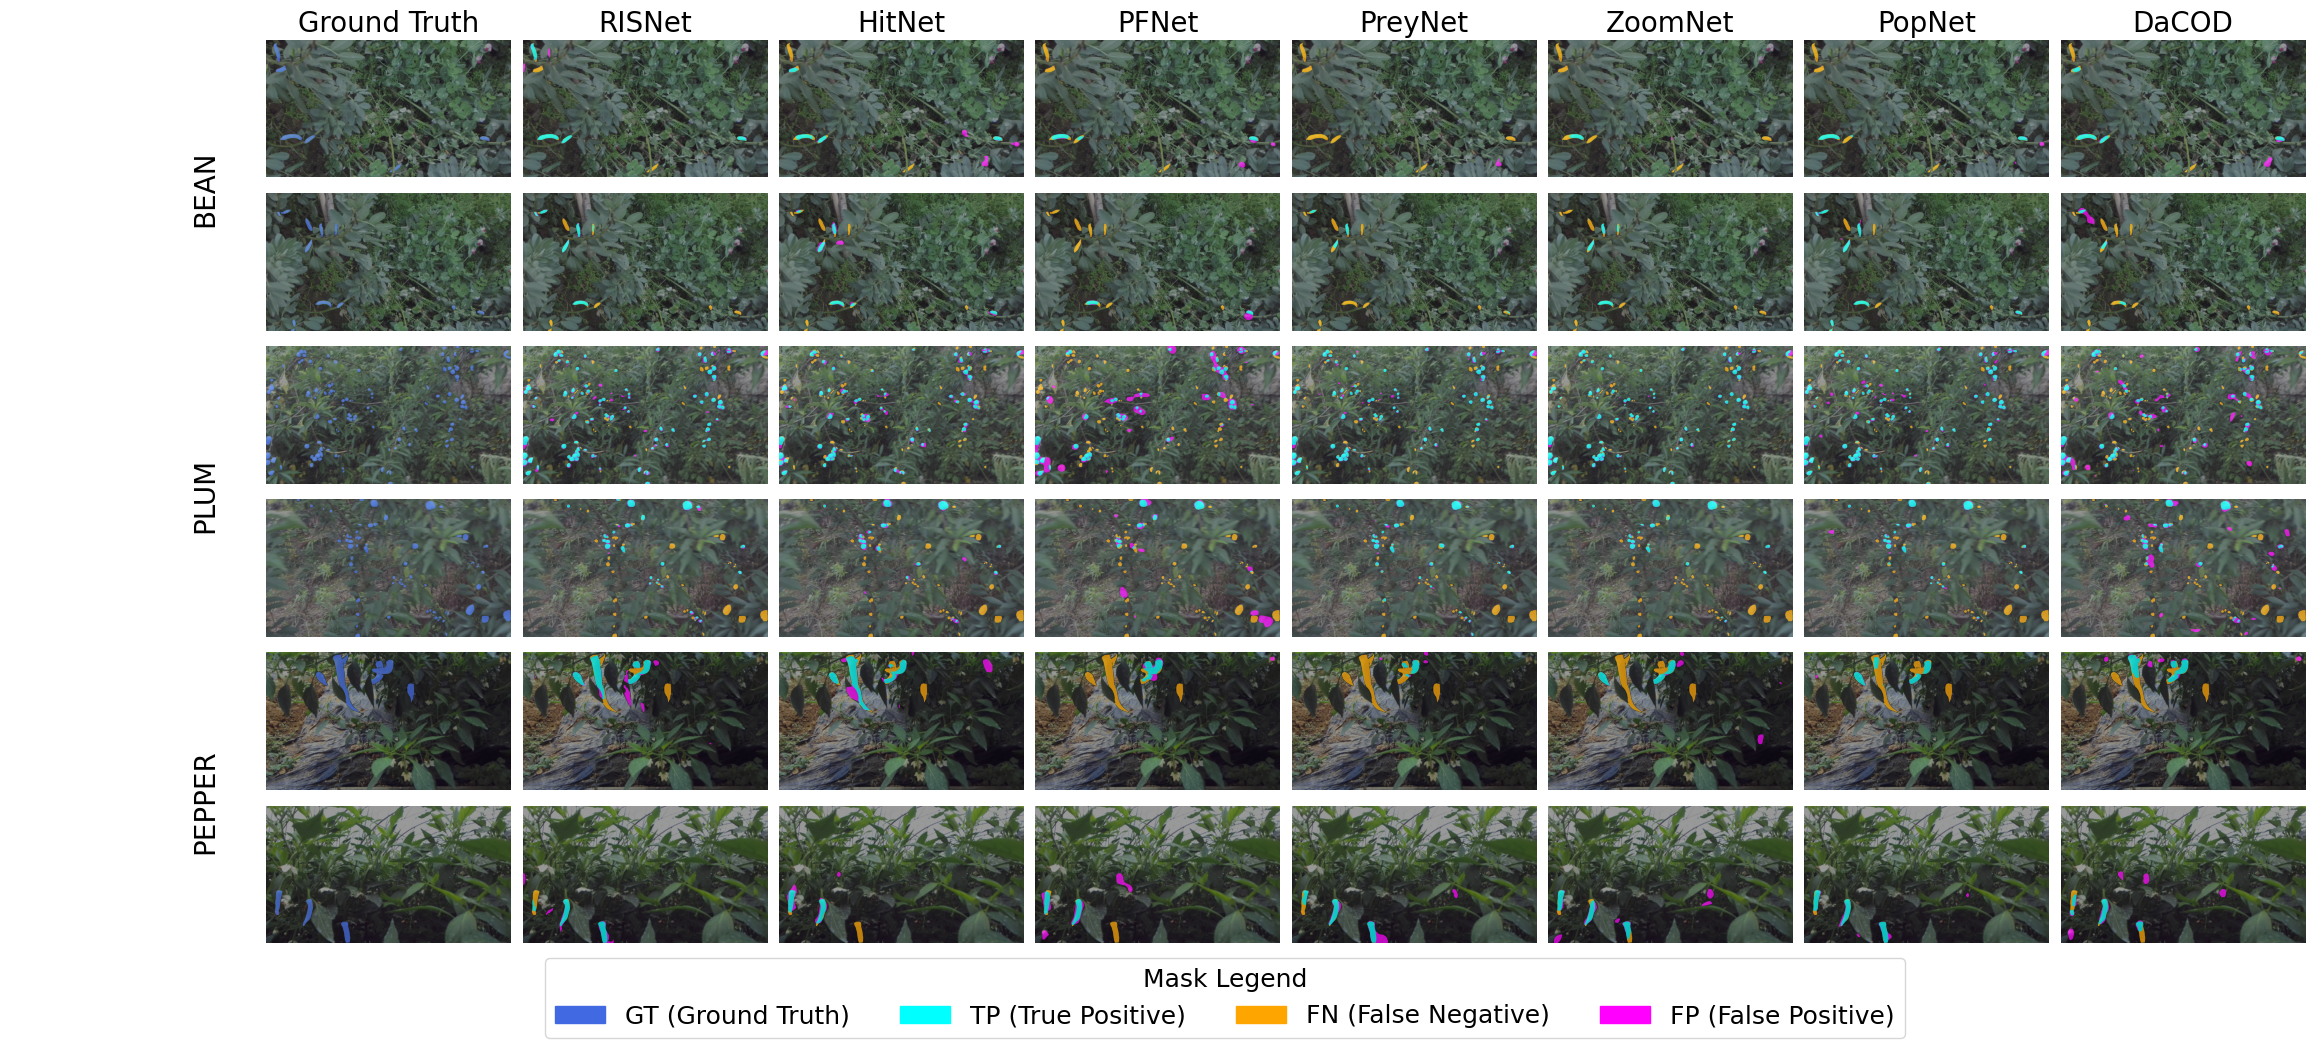

In [24]:
importlib.reload(utils)
utils.display_images3(images=2, 
                      image_files=ACOD_results, 
                      title=f"Difficult Crop Results for Top Performing Networks for ACOD-12K", 
                      save_path=f"results-difficult-crops-top.png", 
                      networks=top_networks_difficult_crops, 
                      crops=difficult_crops,
                      pred_network_roots=["Results/Default/" + network + "/ACOD-12K/" for network in top_networks_difficult_crops], label_fontsize=20)

In [25]:
PreyNet_Networks = ["RISNet", "RISNet_NoDepth", "PreyNet", "PreyNet_w_PVT"]
utils.display_images2(images=5, image_files=ACOD_results_list, title=f"PreyNet Augmentation Comparison", save_path=f"PreyNet-aug-comp.png", networks=PreyNet_Networks, pred_network_roots=["Results/" + network + "/ACOD-12K/" for network in PreyNet_Networks])

FileNotFoundError: [Errno 2] No such file or directory: 'Results/RISNet/ACOD-12K/pepper_left_00782.png'

<Figure size 1562.5x753.125 with 0 Axes>

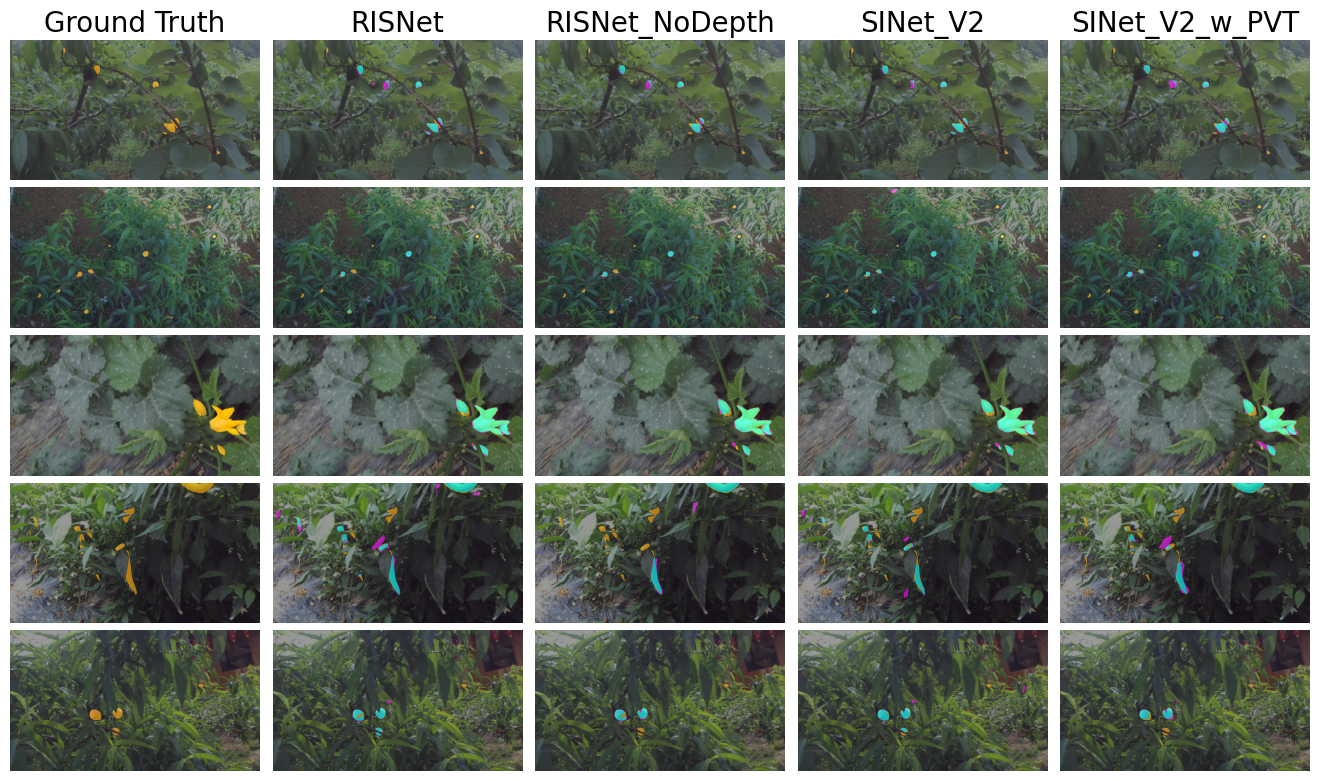

In [ ]:
SINetV2_Networks = ["RISNet", "RISNet_NoDepth", "SINet_V2", "SINet_V2_w_PVT"]
utils.display_images2(images=5, image_files=ACOD_results_list, title=f"SINetV2 Augmentation Comparison", save_path=f"SINetV2-aug-comp.png", networks=SINetV2_Networks, pred_network_roots=["Results/" + network + "/ACOD-12K/" for network in SINetV2_Networks])